In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("hw04.ipynb")

# 🌌 Homework 4: Visualization

### Due Date: Sunday, March 1, 11:59 PM
You must submit this assignment to Pensieve by the on-time deadline, Sunday, March 1, 11:59 PM. Please read the syllabus for the Slip Day policy. No late submissions beyond what is outlined in the Slip Day policy will be accepted. **We strongly encourage you to submit your work to Pensieve several hours before the stated deadline.** This way, you will have ample time to reach out to staff for support if you encounter difficulties with submission. While course staff is happy to help guide you with submitting your assignment ahead of the deadline, we will not respond to last-minute requests for assistance.

Please read the instructions carefully when submitting your work to Pensieve. 

## 👥 Collaboration Policy

Data science is a collaborative activity. While you may talk with others about the homework, we ask that you **write your solutions individually**. If you discuss the assignments with others, please **include their names** below.

## ✅ Grading
As always, grading will be down into auto-graded answers and manually-graded (written) answers. Most of the plots will be manually graded. Your plots should be *similar* to the given examples. We will accept small variations, such as color differences or slight variations in scale. However, it is in your best interest to make the plots as similar as possible. 

**Note:** ALL plotting questions from here on out, we will expect **descriptive titles, axis labels, legends, etc**. The following question serves as a good guideline on what is "enough": *If I directly downloaded the plot and viewed it, would I be able to tell what was being visualized without knowing the question*

## 💯 Score Breakdown

Question | Manual | Points
--- |---| ---
1a | No |2
1b | Yes |1
1c | Yes | 1.5
2a | Yes | 1
2bi | Yes | 1
2bii | Yes | 1
2c | Yes | 1.5
2d | Yes | 0
2e | Yes | 2
3a | Yes |1
3bi | Yes | 0.5
3bii | Yes | 1.5
3ci | Yes | 1
3cii | Yes | 1
3d | Yes | 1
4a | Yes | 1
4b | Yes | 1
4c | Yes | 2
Total | 17 | 22

## 🏎️ Before You Start

For each question in the assignment, please write down your answer in the answer cell(s) right below the question. 

We understand that it is helpful to have extra cells breaking down the process towards reaching your final answer. If you happen to create new cells below your answer to run code, **NEVER** add cells between a question cell and the answer cell below it. It will cause errors when we run the autograder, and it will sometimes cause a failure to generate the PDF file.

**Important note: The local autograder tests will not be comprehensive. You can pass the automated tests in your notebook but still fail tests in the autograder.** Please be sure to check your results carefully.

Finally, unless we state otherwise, **do not use for loops or list comprehensions**. The majority of this assignment can be done using built-in commands in `pandas` and `NumPy`.  Our autograder isn't smart enough to check, but you're depriving yourself of key learning objectives if you write loops / comprehensions, and you also won't be ready for the midterm.

### Debugging Guide
If you run into any technical issues, we highly recommend checking out the [Data 100 Debugging Guide](https://ds100.org/debugging-guide/). In this guide, you can find general questions about Jupyter notebooks / Datahub, Pensieve, and common `pandas` errors.

# Plotting and LLMs
One of the biggest immediate impacts of large-language models (LLMs) on data science: **It's now a lot easier to write code to make plots.**

- Before ChatGPT, code to produce plots could take a long time to write. You often had to spend a lot of time reading extensive documentation and searching online forums for responses from analysts who tried to plot something similar. 
- It could also take a lot of time to reshape and reformat the data to make it compatible with plotting functions. 
- This was one of the most time-consuming parts of Josh's and Ramesh's data science work before the release of ChatGPT!

LLMs can often write the code corresponding exactly or almost exactly to your **plain language description of a plot**. 

- In other words, we can now spend more on the "what" and "why" of our plots, as opposed to the "how". 

In light of this change, the Data 100 visualization homework has evolved. Rather than provide you with a written description of many plots and have you write code to reproduce them, we have flipped the script: **We want you to spend more time thinking about what you want to plot and why you should plot it.**

- While you will still write some plotting code in this assignment, we think it's important to recognize that many standard plot creation tasks can now be carried out by AI, so long as you provide **specific and clear instructions**. 

- But, as you will see while working on this assignment, identifying and describing a plot can be a challenging task. It's an essential skill of a good data scientist.

Of course, we want to recognize that not everyone enrolled in Data 100 feels comfortable using AI tools, and that is OK! **AI is not required for this assignment.** 

- However, throughout this assignment, we will include tips for how to use AI productively for plotting tasks. 

- Please note that the [Data 100 LLM policy](https://ds100.org/sp26/syllabus/#collaboration-policy-and-academic-honesty) still applies in this assignment. **You cannot copy and paste anything from this assignment directly into an LLM.**

In [1]:
# Run this cell to set up your notebook. Make sure ds100_utils.py is in this assignment's folder
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import zipfile
from pathlib import Path
import ds100_utils

# Default plot configurations
%matplotlib inline
plt.rcParams['figure.figsize'] = (16,8)
plt.rcParams['figure.dpi'] = 150
sns.set()

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display, Latex, Markdown

BAY_AREA_COUNTIES = ["Alameda", "Contra Costa", "Marin", "Napa", "San Francisco", "San Mateo", "Santa Clara", "Solano", "Sonoma"]


<br>

---

# Question 1: Recreate an existing plot
Recall the `babynames` dataset from earlier in the course. In [**this article**](https://nightingaledvs.com/the-endless-stories-in-baby-name-data/), data journalist Emma Rubin reveals some interesting trends in baby names. 

For example, Emma identified a steep decline in the share of babies with unique names in the first half of the 20th century, and a rapid resurgence in unique names since the 1960s:

<img src='images/unique_names_chart.png' width = 500px/>

**Your task**: Recreate this plot using the `babynames` dataset and `seaborn`. 

We're going to help you build this plot step-by-step. Make sure to run the code cell below.

In [2]:
# Here is code that imports the babynames dataframe for you
# Note: In other settings, the babynames dataframe refers to babynames in California
#       For this problem, we use babynames across all states.
import os.path
import zipfile

local_filename = "data/names.zip"

all_dfs = []

with zipfile.ZipFile(local_filename, 'r') as zf:
    yearly_files = [f for f in zf.namelist() if f != 'NationalReadMe.pdf']
    for filename in yearly_files:
        year = int(filename[3:7])
        with zf.open(filename) as fh:
            df = pd.read_csv(
                fh,
                header=None,
                names=['Name', 'Sex', 'Count']
            )
            df['Year'] = year
            all_dfs.append(df)

babynames = pd.concat(all_dfs, ignore_index=True)
babynames = babynames[['Year', 'Name', 'Sex', 'Count']]
babynames

,Year,Name,Sex,Count
0,1880,Mary,F,7065
1,1880,Anna,F,2604
2,1880,Emma,F,2003
3,1880,Elizabeth,F,1939
4,1880,Minnie,F,1746
...,...,...,...,...
2149472,2024,Zylyn,M,5
2149473,2024,Zymiere,M,5
2149474,2024,Zypher,M,5
2149475,2024,Zyre,M,5


<br>

---
### Question 1a

Published plot for reference:

<img src='images/unique_names_chart.png' width = 400px/>

A helpful heuristic: In general, each "point" in a plot should correspond to one row of your plotted dataframe. See [tidy data](https://vita.had.co.nz/papers/tidy-data.pdf).

- For example, in the `babynames` plot above, one "point" represents the number of unique names per 1000 babies for **one possible combination of sex and year** in `babynames`.

- Note how this is very similar to the concept of **granularity** from the EDA lecture.

 Let's make a grouped dataframe for plotting called `counts_by_sex_year` where each row represents one point in the plot above. 
 
 Here are the columns that should be in `counts_by_sex_year`:

 - `Sex`

 - `Year`
 
 - `num_unique_names`: The number of unique baby names for every combination of sex and year observed in `babynames`. 
 
 - `tot_births`: The total number of babies born for each combination of sex and year.

 - `unique_names_per_1000_births`: The number of unique names per 1000 babies for each combination of sex and year. 

 Hints: 
 
 - You have learned about the `sum` and `mean` functions for use in `.agg`. There is another `.agg` function called `nunique` that counts the number of unique elements.

 - By default, all grouped columns will become the index of the resulting dataframe. You can use `.reset_index()` to turn them into regular columns. *Note: This is a very common way to end a `.groupby()` statement!*

 AI Guidance: 
 
 - Try not to use AI to help you with this question. 
 
 - Aside from the new `nunique` function mentioned in the hints, everything in this question could be asked on an exam. The [Data 100 reference sheet](https://ds100.org/sp26/assets/exams/fa25/fa25_mt1_reference_sheet.pdf) may come in handy.

In [10]:
counts_by_sex_year = babynames.groupby(['Year', 'Sex']).agg({
    'Name': 'nunique',
    'Count': 'sum'
}).rename(columns={
    'Name': 'num_unique_names',
    'Count': 'tot_births'
}).reset_index()
counts_by_sex_year['unique_names_per_1000_births'] = (counts_by_sex_year['num_unique_names'] / counts_by_sex_year['tot_births']) * 1000
counts_by_sex_year

,Year,Sex,num_unique_names,tot_births,unique_names_per_1000_births
0,1880,F,942,90994,10.352331
1,1880,M,1058,110490,9.575527
2,1881,F,938,91953,10.200863
3,1881,M,996,100735,9.887328
4,1882,F,1028,107847,9.532022
...,...,...,...,...,...
285,2022,M,14322,1744373,8.210400
286,2023,F,17597,1602645,10.979974
287,2023,M,14206,1708551,8.314648
288,2024,F,17661,1613188,10.947887


In [ ]:
grader.check("q1a")

<!-- BEGIN QUESTION -->

<br>

---

### Question 1b

Published plot for reference:

<img src='images/unique_names_chart.png' width = 400px/>

Next, use `counts_by_sex_year` and `sns.lineplot` ([documentation](https://seaborn.pydata.org/generated/seaborn.lineplot.html)) to create a "baseline" version of the published plot with no additional formatting.  

- `sns.lineplot` works very similarly to the plotting functions we've already seen in lecture and lab. You can see some examples of how `sns.lineplot` is used in the demos for Lectures 7 and 8.

- Your answer should be just one line of code! 

Hints: 

- Fill in the blanks of `sns.lineplot(x=..., y=..., hue=..., data=...)`.

 AI Guidance: 
 
 - Try not to use AI to help you with this question. 
 
 - Everything in this question could be asked on an exam. The [Data 100 reference sheet](https://ds100.org/sp26/assets/exams/fa25/fa25_mt1_reference_sheet.pdf) may come in handy.

<Axes: xlabel='Year', ylabel='unique_names_per_1000_births'>

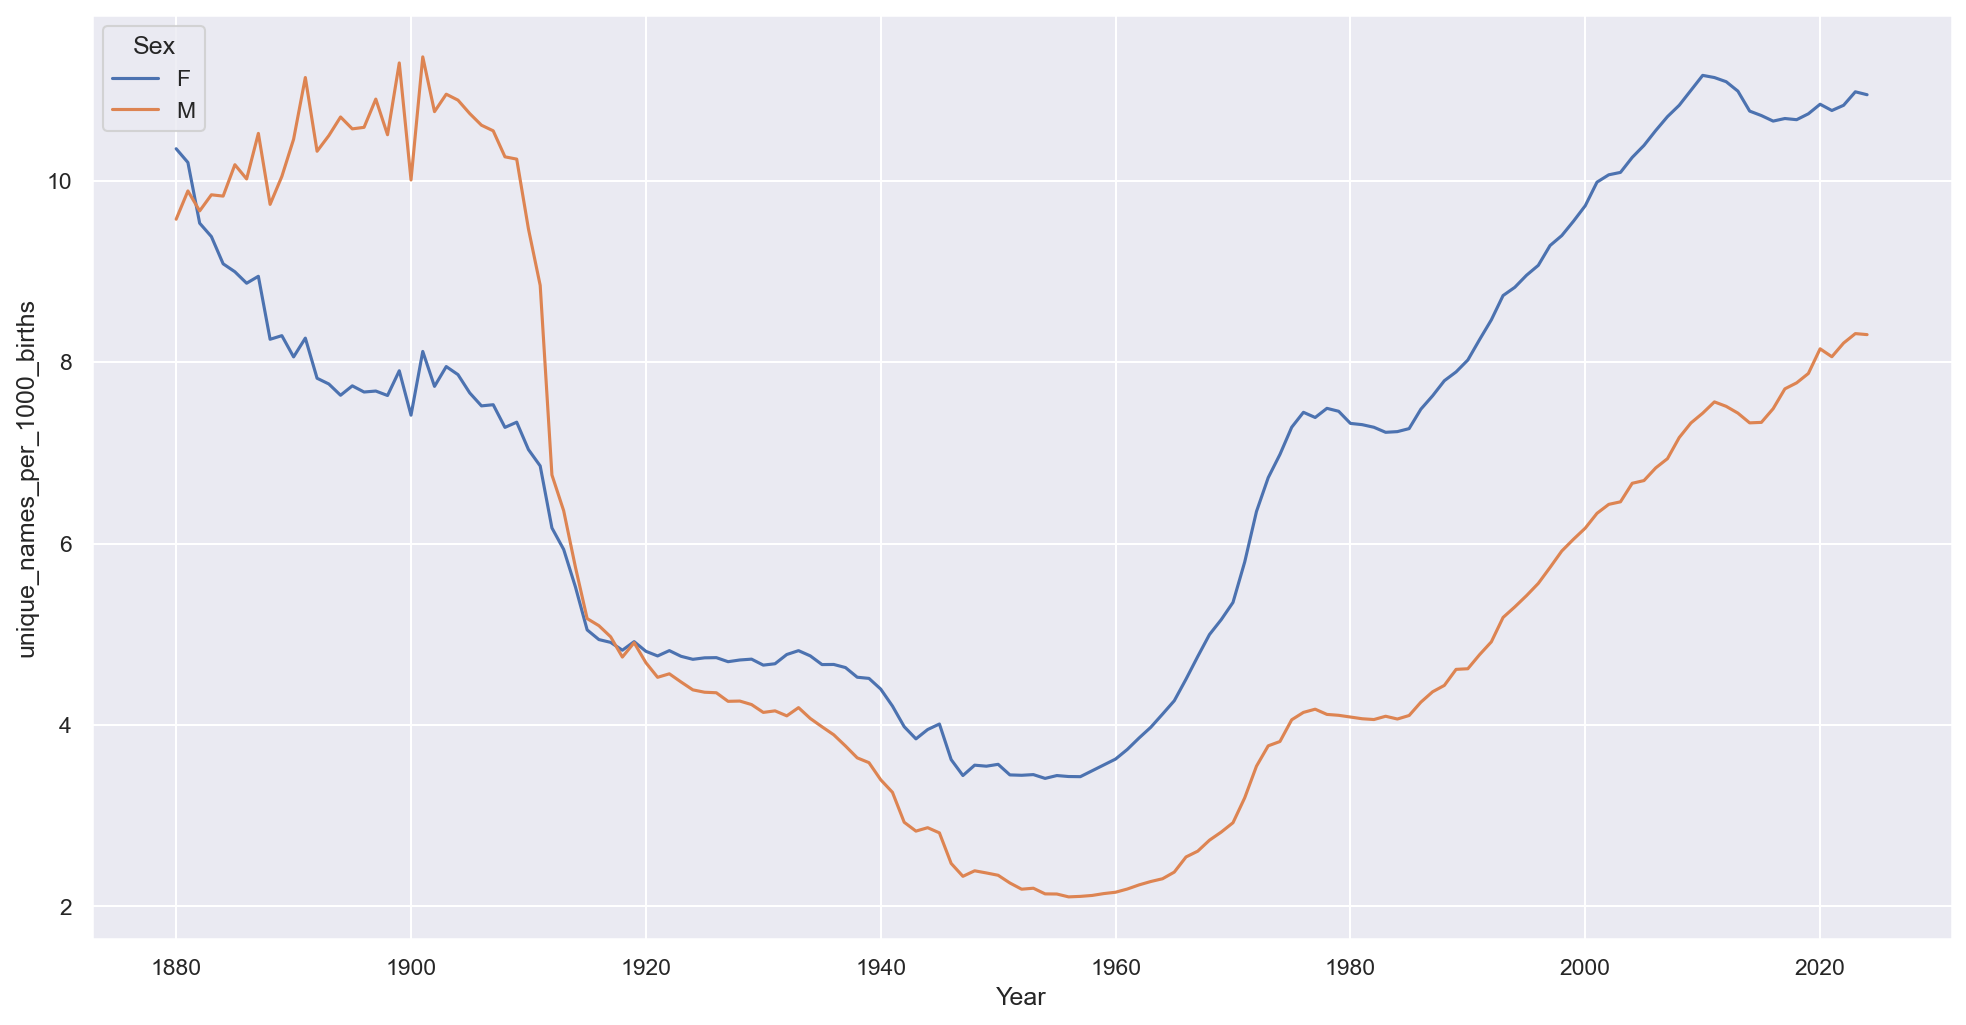

In [11]:
sns.lineplot(data=counts_by_sex_year, x='Year', y='unique_names_per_1000_births', hue='Sex')

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---

### Question 1c

Published plot for reference:

<img src='images/unique_names_chart.png' width = 400px/>

It's time to format our plot! 

Using Google or an LLM to help you, implement the key plot features that differ between your baseline plot and the published `babynames` plot above.

Your recreated plot does not need to be exactly the same as the published plot, but the substantive elements should be the same. Specifically, your plot should have the following:
- The same text (or lack thereof) in the title and axis labels.
- A white background. Check out this webpage: `sns.theme`[documentation](https://python-graph-gallery.com/104-seaborn-themes/).
- A written label of "male" and "female" somewhere above, below, on top of, or next to the corresponding line in the plot. **It is OK to hardcode positions of text.**
- No legend. For this plot, directly labeling lines is easier for the reader!

Here are some details you **do not** need to worry about (but, if you want a challenge, you are welcome to implement them):
- The caption. 
- Fonts. Seaborn defaults are fine!
- The same style of gridlines. It's OK to have horizontal and vertical gridlines.
- Exactly the same numbers and scale along the axes. They just have to be similar.
- The size and resolution of the plot.
- The exact position and orientation of axis labels and data labels
- The exact matching of colors or shading
- The exact position of axis ticks near the edges of the plot

Remember that `seaborn` is built on top of `matplotlib`, so `matplotlib` functions like `plt.title(...)` will also work with `seaborn`.

Hints:

- Google or an LLM may suggest you assign your plot to a variable called `ax`. For example, `ax = sns.lineplot(...)`. While you are welcome to do this, it is not required for this question. We recommend you just use `plt` functions, like `plt.title(...)`.

AI Guidance: 

- If you decide to use an LLM to help you, questions like *"How do I add custom text to a plot in seaborn?"* or *"How do I remove the legend of a seaborn plot?"* are appropriate to ask!

Here's the published plot for reference one more time:

<img src='images/unique_names_chart.png' width = 400px/>

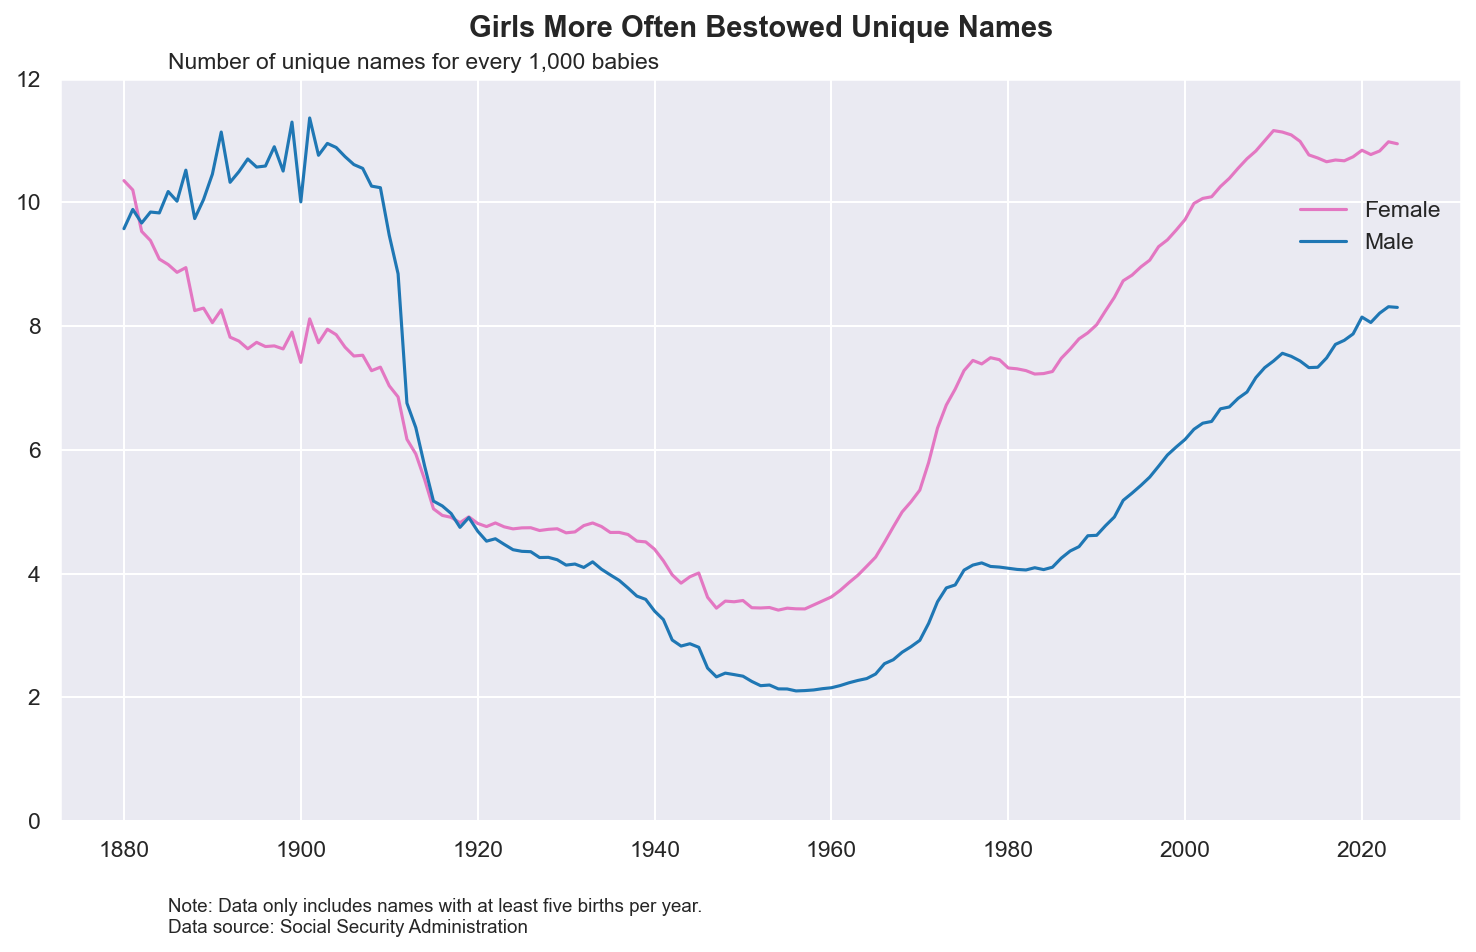

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=counts_by_sex_year, x='Year', y='unique_names_per_1000_births', 
             hue='Sex', hue_order=['F', 'M'], palette={'F': '#e377c2', 'M': '#1f77b4'})

# Title and subtitle with spacing
plt.title("Girls More Often Bestowed Unique Names", fontsize=14, fontweight='bold', pad=20)
plt.figtext(0.12, 0.91, "Number of unique names for every 1,000 babies", fontsize=11)

# Axes
plt.xlabel("")
plt.ylabel("")
plt.ylim(0, 12)

# Replace legend labels
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Female', 'Male'], loc='right', bbox_to_anchor=(1, 0.8), frameon=False)

# Footnote
plt.figtext(0.12, -0.05, "Note: Data only includes names with at least five births per year.\nData source: Social Security Administration", fontsize=9)

plt.tight_layout()


<!-- END QUESTION -->

<br>

---

# Question 2: Improving existing plots

In this question, you will work to improve visualizations that show complex air quality information across geographic locations and over time. We'll be working with data from the EPA on [particulate matter](https://en.wikipedia.org/wiki/Particulate_matter): that is, microscopic particles in the air that can have serious negative effects on human health. The kind we're looking at, PM2.5, are very small particles that commonly arise from pollution and/or wildfires.

You can also view real-time data from these sensors at [AirNow](https://fire.airnow.gov/#7.97/37.894/-122.246) or from low-cost privately owned sensors at [PurpleAir](https://map.purpleair.com/air-quality-standards-us-epa-aqi?opt=%2F1%2Fi%2Flp%2Fa10%2Fp604800%2FcC5#8.7/37.7666/-122.1987). Note that both give you some control over the visualization, but only PurpleAir lets you see PM2.5 levels in $\mu g/m^3$

The `pm25` dataframe contains data from many different air quality sensors (sites) all over California from different days in 2022. The columns are as follows:
* `State Name`, `County Name`, `City Name`, `Address`, `Latitude`, and `Longitude` give information about the location of the sensor.
* `Date Local`: when the measurement was taken
* `AQI`: the [air quality index](https://en.wikipedia.org/wiki/Air_quality_index), derived from the PM2.5 value. We won't be using this column in this question.
* `PM2.5`: the measured PM2.5 concentration in micrograms per cubic meter or $\mu g / m^3$ (average for the day)
* `County Code`: a standardized number (the [FIPS code](https://en.wikipedia.org/wiki/FIPS_county_code)) representing each county
* `Site Num` gives an identifier for the site where the air quality sensor is. **Note that site numbers are only unique per county (i.e., two different sensors in different counties can have the same `Site Num`).**
* `Local Site Name` gives a human-readable description of where the sensor is.
* `fips` contains a number representing the county and the state.

In [40]:
pm25 = pd.read_csv('data/PM2.5_CA_2022.csv', dtype={'fips': 'str'})
pm25['Date Local'] = pd.to_datetime(pm25['Date Local'])
pm25['Site Num'] = pm25['Site Num'].astype(str)
pm25.head()

,State Name,County Name,City Name,Date Local,AQI,PM2.5,County Code,Site Num,Latitude,Longitude,Local Site Name,Address,fips
0,California,Alameda,Livermore,2022-01-01,58.0,12.7,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
1,California,Alameda,Livermore,2022-01-02,60.0,13.9,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
2,California,Alameda,Livermore,2022-01-03,39.0,7.1,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
3,California,Alameda,Livermore,2022-01-04,21.0,3.7,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
4,California,Alameda,Livermore,2022-01-05,23.0,4.2,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001


<!-- BEGIN QUESTION -->

<br>

---

## Question 2a
Before we can create useful visualizations, we have to understand what each row of the dataframe represents. 

What is the granularity of the `pm25` dataframe? 

- To help you determine the granularity, feel free to make a scratch cell and explore the dataframe for yourself. 

> Note: Be specific! Answers that are not specific enough will not receive full credit. To get a sense of the detail required for questions about granularity, we recommend looking at [past Data 100 exams](https://ds100.org/sp26/resources/#exam-resources) and searching for "granularity".

Each row represents one PM2.5 measurement from one air quality sensor site on one day.

<!-- END QUESTION -->

## Question 2b

Consider the following plot, which attempts to visualize PM2.5 levels across the Bay Area in 2022:

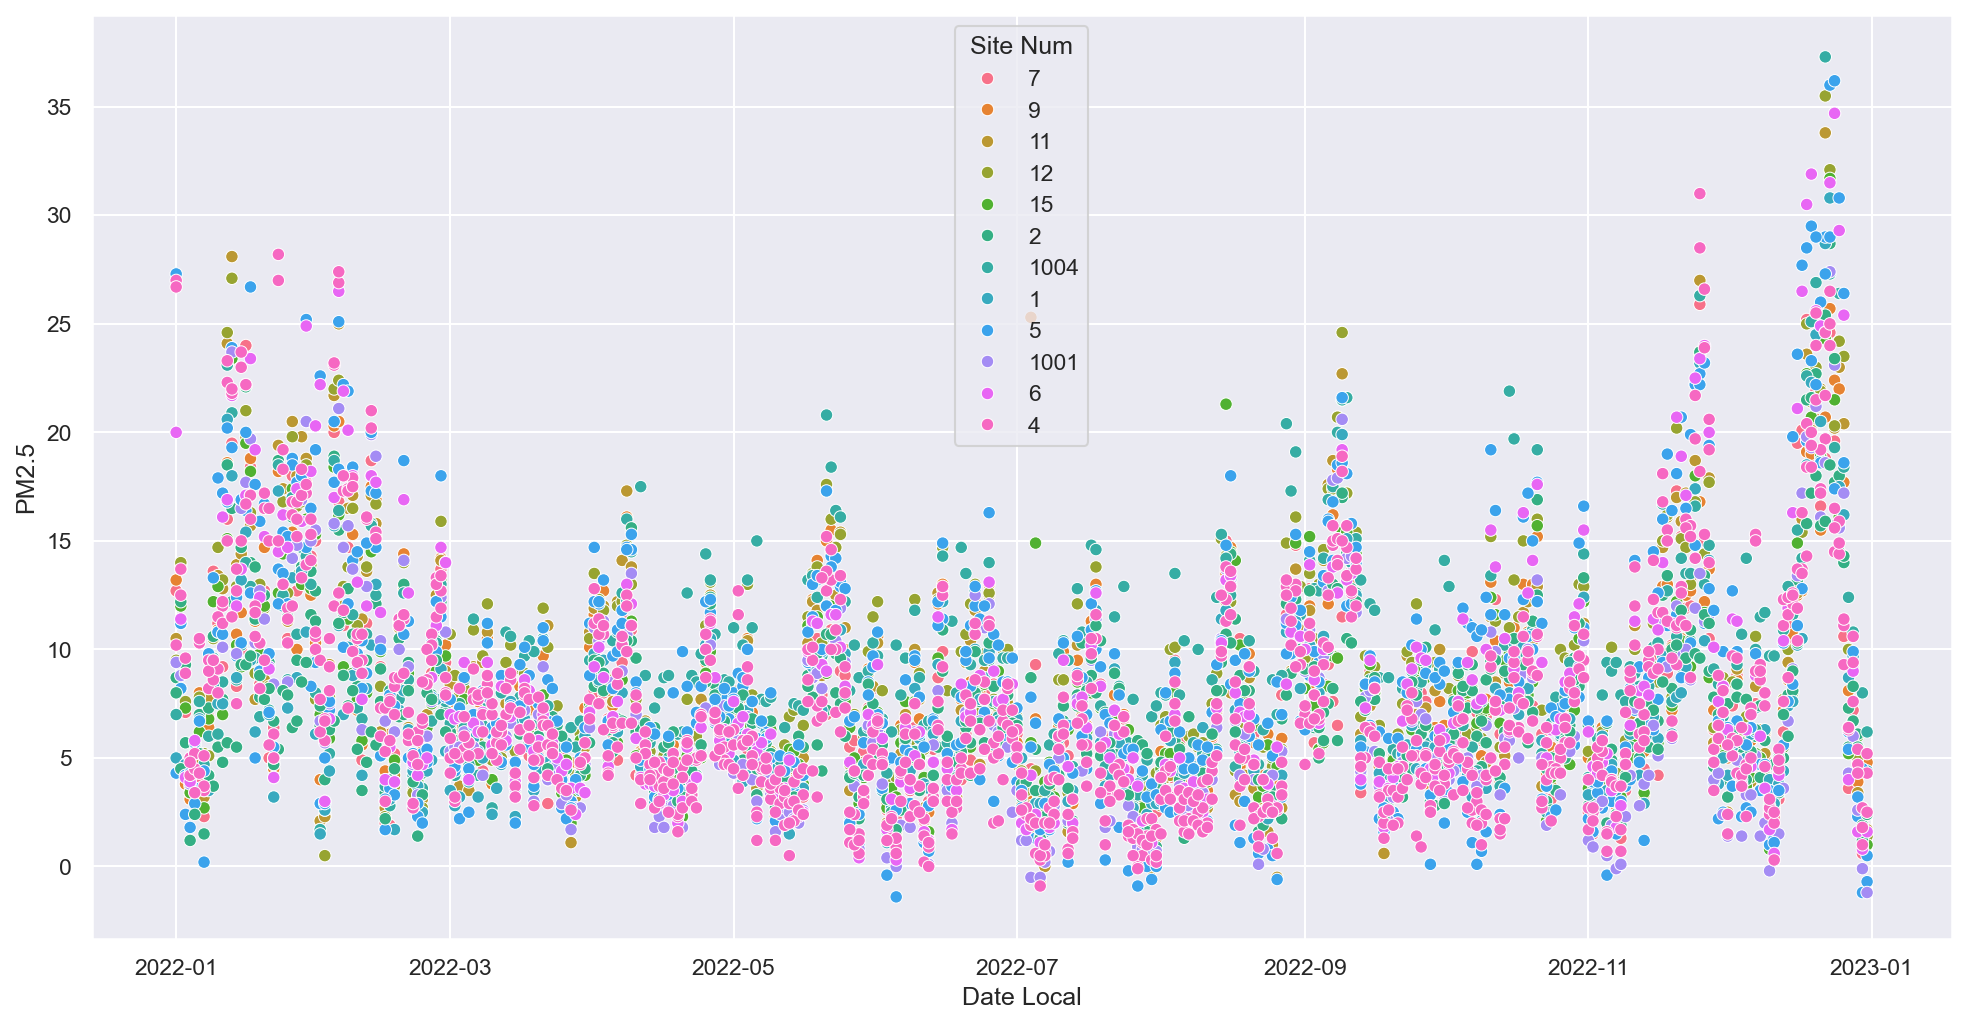

In [41]:
# `BAY_AREA_COUNTIES` is a list of the 9 Bay Area counties. We defined this variable at the top of the notebook.
bay_area = pm25[pm25['County Name'].isin(BAY_AREA_COUNTIES)]
sns.scatterplot(bay_area, x='Date Local', y='PM2.5', hue='Site Num');

<!-- BEGIN QUESTION -->

### Question 2bi
Is each color in the plot above associated with one and only one Bay Area county? Or, can one color be associated with more than one county? Explain your reasoning.

One color can be associated with more than one country, as the question stated that two different sensors in different countries can share the same site number. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Question 2bii
Describe at least **two major visual clarity problems** in this plot that make it difficult to understand trends in PM2.5 across the different Bay Area counties. 

1. The colors don't map to the countries.
2. Too many colors in the legend. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---

### Question 2c

First, using `pm25`, identify the two sites closest to UC Berkeley. 

- You may find it helpful filter `bay_area` to one example row per unique site and inspect the resulting dataframe. See Lecture 3.

Then, generate an improved version of the visualization above that clearly communicates changes in air quality for just these two sites. 

Your visualization should:
* Have clearly understandable axis labels, legend labels, and title
* Avoid common visualization problems as discussed in lecture
* Include a horizontal dotted line or lines that help your viewer identify any important threshold(s) in PM2.5 levels. **You may want to do some external research to help you identify threshold(s)!**

Hints:

- Do a unique site and a unique site number refer to the same thing?

- Like before, Google or an LLM may suggest you assign your plot to a variable called `ax`. For example, `ax = sns.lineplot(...)`. While you are welcome to do this, it is not required for this question. We recommend you just use `plt` functions, like `plt.title(...)`.

AI Guidance: 

- If you decide to use an LLM to help you, questions like *"How do I add a horizontal dotted line to a plot in seaborn?"* are appropriate to ask!

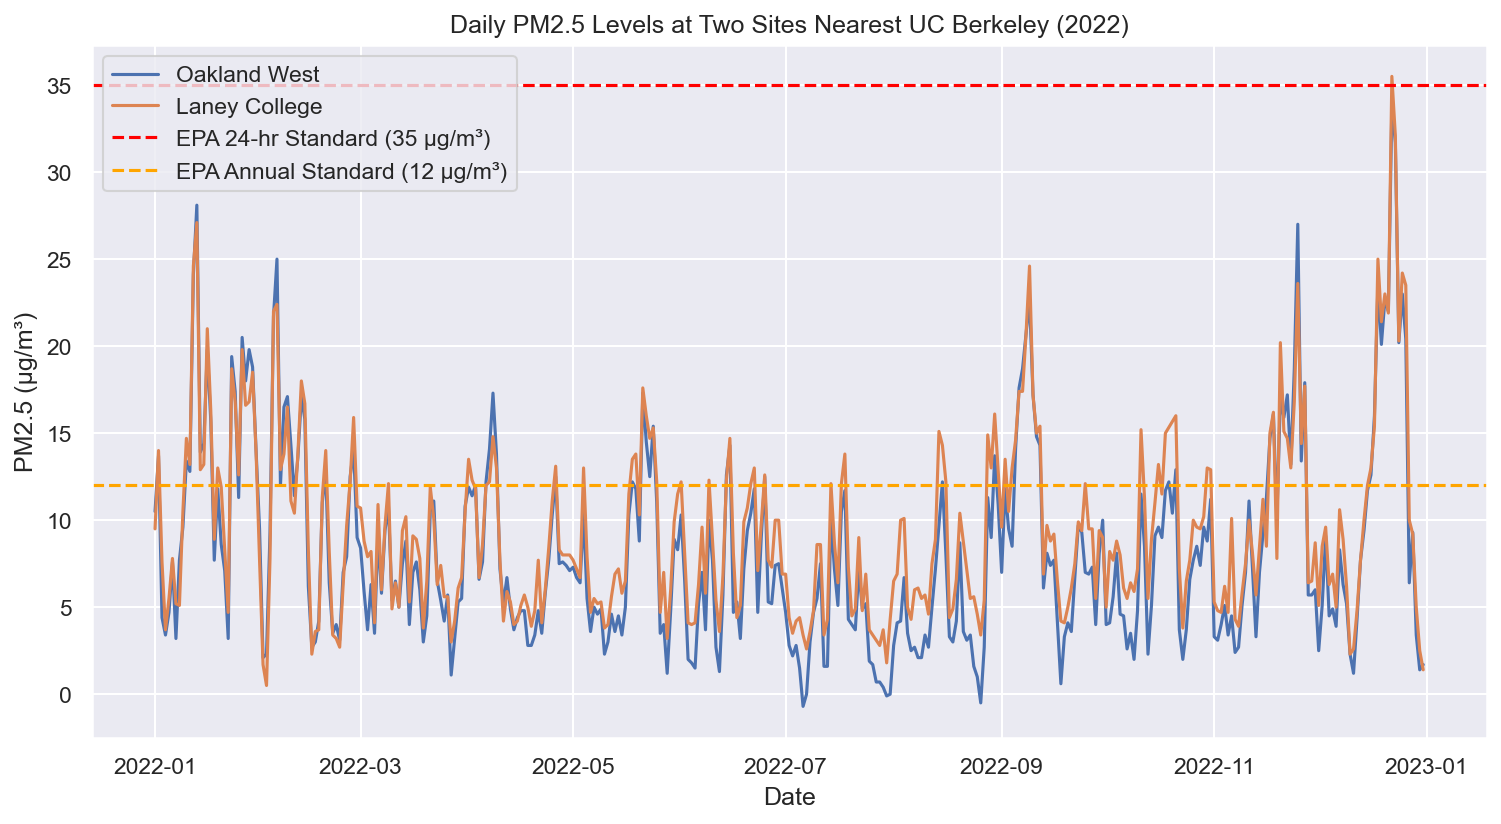

In [52]:
ucb_lat, ucb_lon = 37.8719, -122.2585
# get the two closest sites
bay_area_sites = bay_area.drop_duplicates(subset=['County Code', 'Site Num'])
bay_area_sites = bay_area_sites.copy()
bay_area_sites['distance'] = np.sqrt(
    (bay_area_sites['Latitude'] - ucb_lat)**2 + 
    (bay_area_sites['Longitude'] - ucb_lon)**2
)
bay_area_sites.sort_values('distance').head(2)

# filter to just these two sites
closest_sites = bay_area[bay_area['Local Site Name'].isin(['Oakland West', 'Laney College'])]

plt.figure(figsize=(12, 6))
sns.lineplot(data=closest_sites, x='Date Local', y='PM2.5', hue='Local Site Name')
plt.axhline(y=35, linestyle='--', color='red', label='EPA 24-hr Standard (35 µg/m³)')
plt.axhline(y=12, linestyle='--', color='orange', label='EPA Annual Standard (12 µg/m³)')

plt.title('Daily PM2.5 Levels at Two Sites Nearest UC Berkeley (2022)')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---

### (OPTIONAL) Question 2d

Using what you've learned from part (c) and your answer to part (b), construct your own visualization here that improves upon the original visualization from Question 2b. 

Describe at least one interesting fact that a viewer can learn about PM2.5 trends in or around the Bay Area from your plot.

*Exceptionally good answers to this question might be showcased in lecture or on Ed.*

**This question is optional.**

In [ ]:
...

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---

### Question 2e

Up to now, we have investigated **temporal** trends in PM2.5 levels (i.e., trends over time). For this question, we will think about **spatial** trends (i.e., geographic trends).

In this question, we're going to use a [choropleth](https://en.wikipedia.org/wiki/Choropleth_map) to visualize the **average** PM2.5 level observed for each county in California in 2022. 

- A choropleth is a kind of visualization that uses colors on a map to indicate measurements at different geographical locations. 

Your task:

1. In the code cell below, create a dataframe called `avg_per_county`. There should be one row per county. Each row should contain the average PM2.5 value over all sensors and all days in 2022 for the county corresponding to that row.

2. Use `plotly`'s `px.choropleth`[documentation](https://plotly.com/python-api-reference/generated/plotly.express.choropleth.html) function to visualize the values in `avg_per_county`. 

Hints: 

- Make sure `avg_per_county` contains the `fips` column. `fips` specifies a unique code for each county that `plotly` uses draw the county borders on a map.

- It's OK if your visualization is missing a few counties: Not every county has EPA air quality sensors.

LLM guidance: 

- You may find it helpful to use an LLM to figure out how to make the choropleth visualization using your dataframe. You might ask *How do I make a choropleth with plotly using a dataframe with these columns: \<your columns here\>"*
    

In [55]:
pm25

,State Name,County Name,City Name,Date Local,AQI,PM2.5,County Code,Site Num,Latitude,Longitude,Local Site Name,Address,fips
0,California,Alameda,Livermore,2022-01-01,58.0,12.7,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
1,California,Alameda,Livermore,2022-01-02,60.0,13.9,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
2,California,Alameda,Livermore,2022-01-03,39.0,7.1,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
3,California,Alameda,Livermore,2022-01-04,21.0,3.7,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
4,California,Alameda,Livermore,2022-01-05,23.0,4.2,1,7,37.687526,-121.784217,Livermore,793 Rincon Ave.,06001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39707,California,Ventura,Not in a city,2022-12-27,36.0,6.5,111,3001,34.252390,-119.143182,El Rio-Rio Mesa School #2,"545 CENTRAL AVENUE, OXNARD, CA 93030",06111
39708,California,Ventura,Not in a city,2022-12-28,29.0,5.3,111,3001,34.252390,-119.143182,El Rio-Rio Mesa School #2,"545 CENTRAL AVENUE, OXNARD, CA 93030",06111
39709,California,Ventura,Not in a city,2022-12-29,32.0,5.8,111,3001,34.252390,-119.143182,El Rio-Rio Mesa School #2,"545 CENTRAL AVENUE, OXNARD, CA 93030",06111
39710,California,Ventura,Not in a city,2022-12-30,16.0,2.9,111,3001,34.252390,-119.143182,El Rio-Rio Mesa School #2,"545 CENTRAL AVENUE, OXNARD, CA 93030",06111


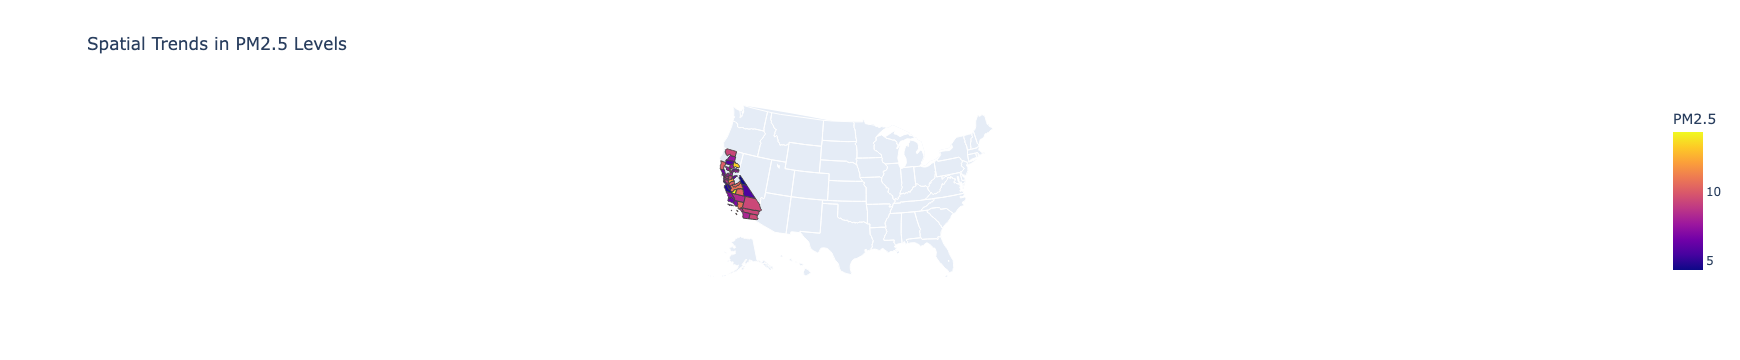

In [61]:
# Your solution must include the fips column for the choropleth to work correctly.
avg_per_county = pm25.groupby(['County Name', 'fips']).agg({'PM2.5':'mean'}).reset_index()

PLOTLY_GEOJSON = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"

fig = px.choropleth(
    avg_per_county,
    geojson=PLOTLY_GEOJSON, # Contains county geometries
    # Your solution here
    locations='fips',
    color= 'PM2.5',
    hover_name='County Name',
    scope="usa",
    title='Spatial Trends in PM2.5 Levels'
)
fig.show()

<!-- END QUESTION -->

# Question 3: Engaging with a plot from research
In their 2013 research paper titled [The Missing “One-Offs”: The Hidden Supply of High-Achieving, Low-Income Students](https://www.brookings.edu/wp-content/uploads/2016/07/2013a_hoxby.pdf), researchers Caroline Hoxby and Chris Avery investigate the behavior of high-achieving low-income applicants to undergraduate programs in the United States.

Hoxby and Avery define a "high-achieving" student as one who scores above the 90th percentile on the ACT or SAT **and** has an average high school GPA corresponding to an A- or higher. They define "low-income" as a family income in the bottom quartile, "upper-income" as the upper quartile, and "middle-income" as those who fall between.

Hoxby and Avery track the college applications of all high school students who graduated in 2008 and took either the ACT or SAT. 

To keep everything on the same scale, Hoxby and Avery converted all ACT and SAT scores to percentiles. 

- For example, a student who scored 1730/2400 on the SAT in 2008 was in the 75th percentile of SAT test takers. 

- A different student who scored 24/36 on the ACT was in the 75th percentile of ACT test takers. 

- In the Hoxby and Avery study, **both of these students are assigned a percentile test score of 75.** 

- Additionally, **if the average ACT score of all enrolled students at College X was 24 (or, equivalent, the average SAT was 1730), Hoxby and Avery assign College X a percentile score of 75.**

Below is Figure 10 of their paper. 

- Each data point used in the plot represents one college application from one student. The data points are aggregated to make the histogram. 

- **Note that these are overlaid (not stacked) histograms.**

<img src='images/Hoxby&Avery_figure10.png' width=600px />

<!-- BEGIN QUESTION -->

<br>

---

### ✈️ Question 3a

Write a caption for this figure. Remember that a caption should not describe every detail in a plot, but it should provide the key takeaway(s). Your caption should be less than 100 words.

**Hints:** 

- To help you understand the horizontal axis, make sure to read the definition of percentile test score for a student versus a percentile test score for a college. These definitions are provided in the introduction to this question.

High-achieving students from all income groups apply most frequently to colleges where the college's median score is slightly below their own (around -10 to 0 percentiles). However, high-income students submit significantly more applications to the most selective colleges (those closest to their own score) compared to low- and middle-income students. Low-income students' applications are more spread out across less selective institutions, suggesting they may be "undermatching" — applying to colleges below their academic ability.

<!-- END QUESTION -->

<br>

---

### 🪔 Question 3b

In this question, we consider the hypothetical dataframe required to reconstruct the "baseline" version of this plot using just a single call to `sns.histplot`. 

- In other words, the hypothetical code to recreate this histogram may use `sns.histplot` **only one time**.

<!-- BEGIN QUESTION -->

###  Question 3b, Part i

What is the granularity of this hypothetical dataframe?

Each row represents one college application from one high-achieving student to one selective institution.

The histogram is built from individual applications — each application has an income group and a "student-college match" score (the difference between the college's median percentile and the student's percentile). Multiple applications from the same student would be separate rows.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

### Question 3b, Part ii

What are the **names**, **variable types**, and **possible values** of the columns in the hypothetical dataframe?

- Every column you state must be necessary to recreate the plot. Do not describe any additional columns. A row ID column is not necessary to recreate a plot.

- Make sure your column names are sufficiently descriptive. 

- Your columns should require no transformations in order to recreate the plot. **You should be able to plug in your stated columns directly into `sns.histplot` with no additional code.**

student_college_match → goes into x= — it's the x-axis showing how selective the college is relative to the student

income_group → goes into hue= — it separates the three overlaid histograms by color

<!-- END QUESTION -->

--- 

### Question 3c

Before publication in a formal venue, such as an academic journal, researchers will sometimes release a working paper. Formal publication can take months or even years of back-and-forth editing. Working papers allow results to be disseminated more quickly. 

Here is the same figure from the Hoxby and Avery [working paper](https://www.nber.org/system/files/working_papers/w18586/w18586.pdf), which was released about a year before the official published paper:

<img src='images/Hoxby&Avery_figure09.png' width=600px />

Published figure for comparison:

<img src='images/Hoxby&Avery_figure10.png' width=400px />

<!-- BEGIN QUESTION -->

<br>

---
### 🦾 Question 3c, Part i

What are the most important changes you observe when comparing the figure from the working paper to the figure from the published paper?  

- Be sure to list **at least three substantive changes**. In the next part, you'll briefly evaluate the impact of each change you list. 
- Examples of non-substantive changes: "The image is smaller in the final plot" or "The figure number was changed from 9 to 10". 
- You should describe each change as something that was done to the working paper version of the plot.

Note: Ramesh and Josh notice at least ten changes!

1. Colors changed — the working paper uses bright blue, brown, and purple. The published version uses muted blue, olive/gold, and a lighter blue. The published palette is more muted and professional.

2. Direct labels added — the published figure has text labels ("Low-income", "Middle-income", "High-income") placed directly on the histogram bars. The working paper puts color-to-income mapping in the subtitle instead.

3. Title changed — the working paper title describes all three income groups and includes technical notes (e.g., "1 student = weight of 1"). The published title is cleaner: "Distribution of All High-Achieving Students' College Applications to Selective Institutions, by Student-College Match."

4. Legend/subtitle simplified — the working paper crams the color key into the subtitle ("blue = low income, brown = middle income, purple = high income"). The published version removes this and uses direct labels instead.

5. X-axis label improved — the working paper says "College's median SAT - student's SAT (scores in percentiles)." The published version says "College's median ACT or SAT score minus student's score (both in percentiles)" — more precise and inclusive of ACT.

6. Source note added — the published version includes a footnote explaining the data source and how to read the overlaid bars.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---

### 👽 Question 3c, Part ii

For each change you listed in part (c), describe the impact of the change on the audience's perception of the plot. 

Do you think the change made the plot easier or harder to understand? Why?

1. Muted colors — easier to understand. The bright blue and purple in the working paper are visually overwhelming and hard to distinguish. The muted palette reduces visual clutter and is more accessible.

2. Direct labels — much easier to understand. Instead of checking back and forth between the subtitle and the bars, you can immediately see which color belongs to which income group.

3. Cleaner title — easier. The working paper title tries to do too much (title + technical notes). The published title is descriptive without being cluttered.

4. Removing color key from subtitle — easier. Subtitles shouldn't serve as legends. Direct labels on the plot are more intuitive.

5. Improved x-axis label — easier. Mentioning both ACT and SAT, and clarifying "both in percentiles," helps the reader understand the scale without needing to read the paper text.

6. Source footnote — easier. Explaining that middle-income bars extend down to zero behind low-income bars clarifies the overlaid (not stacked) design, which could otherwise confuse readers.

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

---

### 🐳 Question 3d

List at least one change to the published figure that you think would improve the interpretation of the plot.

Then, describe the impact of your proposed change(s). 

- Your change(s) should not require additional data or any substantive modification of the existing data.

Published figure for reference:

<img src='images/Hoxby&Avery_figure10.png' width=400px />

Add transparency (alpha) to the bars. Currently, the overlaid histograms hide parts of each other — for example, where high-income bars overlap middle-income bars, you can't see the middle-income values. Adding transparency would let viewers see all three distributions simultaneously without any information being hidden. This would make it easier to compare the shapes of the three distributions, especially in the -20 to 0 range where they overlap most heavily.

<!-- END QUESTION -->

<br>

---

## 📊 Question 4: Designing a hypothetical plot (Open-Ended)

Employers in the United States are required to pay workers a minimum hourly wage. 

- Some groups argue that the minimum wage is too low and should be increased to benefit employees. 

- Other groups argue that raising the minimum wage will force employers to spend more money per employee, which will require employers to either raise prices for consumers or reduce the number of employees. 

Suppose you are interested in studying the effect of raising the minimum wage on prices and the unemployment rate. 

- Assume you have infinite time and infinite resources, you can observe multiple different universes at the same time, and you can collect data about anything in any universe. 

- For example, you can force a change in the minimum wage at one specific business or an entire ZIP code. You do not have to follow the law.

- You can assume the data look any way you would like, but you should be sure the hypothetical data is in realistic units.

**Your task**: Design one hypothetical plot that demonstrates the effect of changing the minimum wage on prices and/or unemployment. 

*Note: Especially strong responses to this question will be showcased either at the beginning of lecture or on Ed!*

<!-- BEGIN QUESTION -->

### Question 4a
Describe your hypothetical visualization in words. 

- What type of plot is it (line plot, overlaid histograms, choropleth, etc.)?

- What is the trend or pattern in your plot? Remember that your data can look any way you would like. There could be a positive, negative, or null effect of changing the minimum wage on prices and unemployment; it's up to you to decide.

- Be sure to describe the title, the axis labels, the numeric scale of the axes, the legend (if applicable), the color palette (if applicable), the caption, and any other key features. 

- Your plot must not be interactive or three-dimensional. In other words, your plot could be printed on a sheet of paper. If you'd like, you are welcome to use more than two variables in your plot, but you cannot use more than two axes.

- Your plot should not be trivial. For example, a bar plot with two bars is essentially just two data points that could have been written as numbers (e.g., the True/False bar plot from Lecture 8). Try to be more creative!

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Question 4b
Provide a description of the hypothetical dataframe that you would need to create your plot.

- What is the granularity of the dataframe? 

- What are in the columns? Make sure to describe the contents of any columns that aren't obvious from the column name.

- What are the possible values in each column?

- How was the data collected?

_Type your answer here, replacing this text._

<!-- END QUESTION -->

### Question 4c
Finally, provide a sketch of your plot. 

Submit this to the HW4 Plot Sketch assignment on [Pensive](http://pensive.co/).

Set `q4c` = `True` once you've done so!

In [ ]:
q4c = ...

In [ ]:
grader.check("q4c")

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Congratulations! You have finished Homework 4!
<img src = "images/robin.jpg" width = "500">

### Course Content Feedback

If you have any feedback about this assignment or about any of our other assignments, lectures, or discussions, please fill out the [Course Content Feedback Form](https://forms.gle/qKAqNBVXYs3wbGE26). Your input is valuable in helping us improve the quality and relevance of our content to better meet your needs and expectations!

### Submission Instructions

Below, you will see a cell. Running this cell will automatically generate a zip file with your autograded answers. Once you submit this file to the HW 4 Coding assignment on Pensieve, Pensieve will automatically submit a PDF file with your written answers to the HW 4 Written assignment. If you run into any issues when running this cell, feel free to check this [section](https://ds100.org/debugging-guide/autograder-gradescope/#why-did-a-gradescope-pensive-test-fail-when-all-the-jupyter-notebooks-tests-passed) in the Data 100 Debugging Guide.

**Important**: Please check that your **plots/graphs and written responses** were generated and submitted correctly to the HW 4 Written Assignment.

**You are responsible for ensuring your submission follows our requirements and that the PDF for HW 4 written answers was generated/submitted correctly. We will not be granting regrade requests nor extensions to submissions that don't follow instructions.** If you encounter any difficulties with submission, please don't hesitate to reach out to staff prior to the deadline. 

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [ ]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)